In [13]:

import pandas as pd
import re
with open("test.ft.txt","r",encoding="utf-8") as f:
  lines=f.readlines()
print(f"Total reviews:{len(lines)}")

def parse_lines(line):
  label = line[:10]
  text = line[11:].strip()
  sentiment="negative" if label == "_label_1" else "positive"
  return sentiment,text
data = [parse_lines(line) for line in lines]
df = pd.DataFrame(data,columns=["sentiment","review"])
df_sample= df.sample(n=5000,random_state=42).reset_index(drop=True)


Total reviews:41686


In [14]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_sample['clean_review'] = df_sample['review'].apply(clean_text)

df_sample[['review', 'clean_review', 'sentiment']].head()


,review,clean_review,sentiment
0,Not your average Floyd tribute: I had purchase...,not your average floyd tribute i had purchased...,positive
1,Abstract and bloody: The album can best be des...,abstract and bloody the album can best be desc...,positive
2,Perfect fit with my Vibram Bikila LS shoes: I ...,perfect fit with my vibram bikila ls shoes i w...,positive
3,Excellent just like the one that comes with th...,excellent just like the one that comes with th...,positive
4,Depends on your Dog: My dog is a flat-coat ret...,depends on your dog my dog is a flatcoat retri...,positive


In [15]:
!pip install vaderSentiment --quiet

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = analyzer.polarity_scores(text)['compound']
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

df_sample['predicted_sentiment'] = df_sample['clean_review'].apply(get_sentiment)

df_sample[['clean_review', 'sentiment', 'predicted_sentiment']].head(10)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.5 MB/s eta 0:00:00


,clean_review,sentiment,predicted_sentiment
0,not your average floyd tribute i had purchased...,positive,neutral
1,abstract and bloody the album can best be desc...,positive,positive
2,perfect fit with my vibram bikila ls shoes i w...,positive,positive
3,excellent just like the one that comes with th...,positive,positive
4,depends on your dog my dog is a flatcoat retri...,positive,positive
5,this book is boring the oxbow incient is probb...,positive,negative
6,easy to read and interesting judaism cannot be...,positive,positive
7,profound poetic and disturbing a terrific read...,positive,negative
8,eww i only watched about a third of this film ...,positive,positive
9,crysis if you have a good machine with at leas...,positive,positive


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

    negative       0.00      0.00      0.00         0
     neutral       0.00      0.00      0.00         0
    positive       1.00      0.70      0.83      5000

    accuracy                           0.70      5000
   macro avg       0.33      0.23      0.28      5000
weighted avg       1.00      0.70      0.83      5000

Overall accuracy: 70.48%


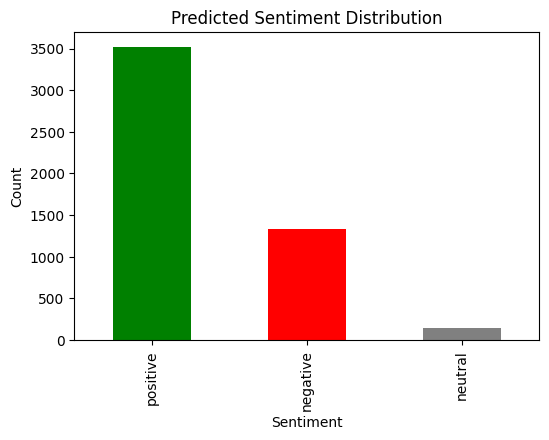

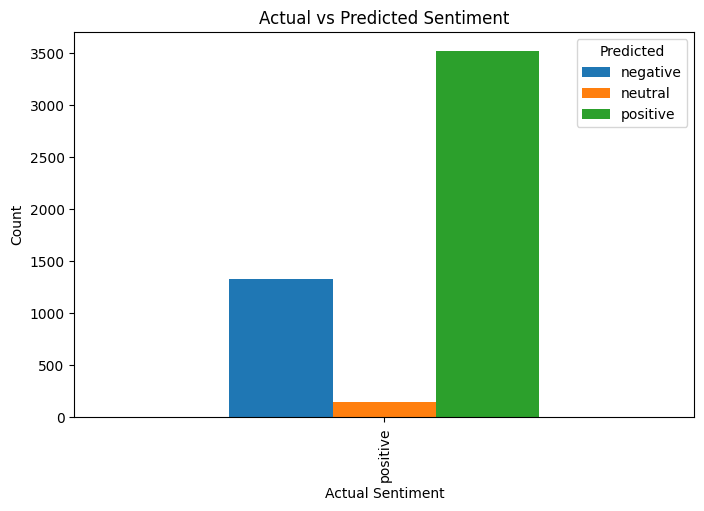

In [16]:
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

print(classification_report(df_sample['sentiment'], df_sample['predicted_sentiment']))

accuracy = accuracy_score(df_sample['sentiment'], df_sample['predicted_sentiment'])
print(f"Overall accuracy: {accuracy:.2%}")

plt.figure(figsize=(6,4))
df_sample['predicted_sentiment'].value_counts().plot(kind='bar', color=['green','red','gray'])
plt.title('Predicted Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

comparison = pd.crosstab(df_sample['sentiment'], df_sample['predicted_sentiment'])
comparison.plot(kind='bar', figsize=(8,5))
plt.title('Actual vs Predicted Sentiment')
plt.xlabel('Actual Sentiment')
plt.ylabel('Count')
plt.legend(title='Predicted')
plt.show()


Using VADER sentiment analysis on a sample of Amazon reviews, the model achieved an accuracy of 70.48% against the actual star-rating-derived labels. It did better on positive reviews . Misclassifications were mostly reviews with mixed language e.g. praising the product but complaining about shipping.But overall result was posivitive about the prodoucts.